<a href="https://colab.research.google.com/github/Rudranxh2007/Dl-lab-case_study3/blob/main/Dl_casestudy_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = "/content/drive/MyDrive/brain_tumor_dataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.6108 - loss: 27.0028 - val_accuracy: 0.6200 - val_loss: 3.4151
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.6059 - loss: 12.2345 - val_accuracy: 0.6800 - val_loss: 2.6109
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.6404 - loss: 6.5105 - val_accuracy: 0.6200 - val_loss: 8.3019
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.6552 - loss: 2.0890 - val_accuracy: 0.7000 - val_loss: 0.8815
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.5961 - loss: 0.9720 - val_accuracy: 0.4000 - val_loss: 0.8499
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.6256 - loss: 0.7531 - val_accuracy: 0.4800 - val_loss: 1.2768
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.6453 - loss: 0.7458 - val_accuracy: 0.6400 - val_loss: 0.6796
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step -

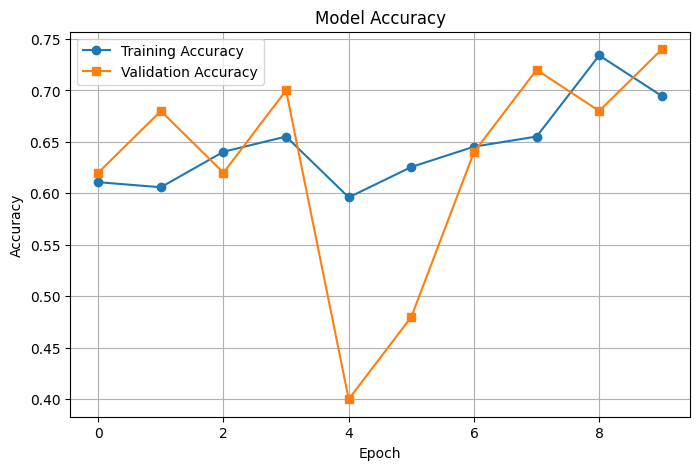

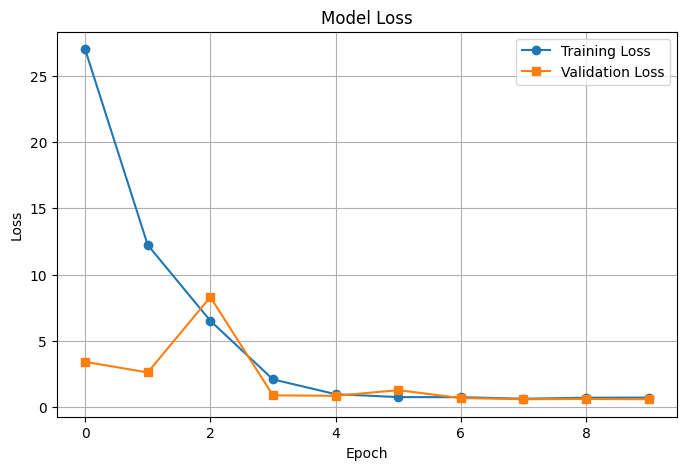

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

img_size = 224
batch_size = 32


datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)



train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),input_shape=(224,224,3)))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(64,(3,3)))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(128,(3,3)))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.25))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(2,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)

# Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], marker='s', label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()


plt.show()

# Loss Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='s', label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()


plt.show()